In [ ]:
#hide
import fastbook

In [1]:
#hide
from fastbook import *
from fastai.vision.widgets import *

In [12]:
subscription_key = "1e16fe7078f34c868102c3b41c1bb816"
search_term = "grizzly bear"

# From Model to Production

## The Practice of Deep Learning

### Starting Your Project

### The State of Deep Learning

#### Computer vision

#### Text (natural language processing)

#### Combining text and images

#### Tabular data

#### Recommendation systems

#### Other data types

### The Drivetrain Approach

## Gathering Data

# clean
To download images with Bing Image Search, sign up at Microsoft for a free account. You will be given a key, which you can copy and enter in a cell as follows (replacing 'XXX' with your key and executing it):

In [48]:
import requests
import json

# THIS IS WHAT THE COURSE USES
# https://docs.microsoft.com/en-us/azure/cognitive-services/bing-image-search/quickstarts/client-libraries?tabs=visualstudio&pivots=programming-language-python

#REST API
#References
#https://docs.microsoft.com/en-us/bing/search-apis/bing-image-search/quickstarts/rest/python
#https://forums.fast.ai/t/02-production-permissiondenied-error/65823/27
#https://forums.fast.ai/t/getting-the-bing-image-search-key/67417/67
#https://fastcore.fast.ai/#L 
#https://fastcore.fast.ai/foundation.html#L
#https://docs.python.org/3/tutorial/datastructures.html

# Defining function(args) // **kwargs: optional arguments that json.loads takes 
def search_images_bing(subscription_key, search_term, image_count : int = 150, **kwargs):
    
    #API Endpoint
    search_url = "https://api.bing.microsoft.com/v7.0/images/search"
   
    #Create dictionary{key,value}
    headers = {"Ocp-Apim-Subscription-Key" : subscription_key} # azure key
    params  = {"q": search_term, "license" : "public", "imageType" : "photo", "count" : image_count} # search request parameters
   
    #Get request to Bing Image Search API, returns response objects
    response = requests.get(search_url, headers=headers, params = params)
    response.raise_for_status() # Catches if HTTP error occurs 
    search_results = response.json() # Returns json-encoded response
    return L(search_results['value']) #Returns L class, fastcore equivalent to Python lists and numpy

In [49]:
search_images_bing

<function __main__.search_images_bing(subscription_key, search_term, image_count: int = 150, **kwargs)>

In [104]:
# Function call
from IPython.display import Image
from IPython.core.display import HTML 

results = search_images_bing(subscription_key, search_term, min_sz=128)

# Check 150 items were retrieved (contentUrl can be replaced with any key contained in results)
ims = results.attrgot('contentUrl')
len(ims) # 150 should be expected

150

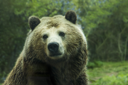

In [108]:
from PIL import Image
# Settings dest to specified local path and opening image
dest = Path('../images/grizzly.jpg')
test_im = Image.open(dest)
im.to_thumb(128,128)

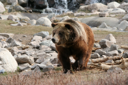

In [109]:
# Checks if dest file exist, if it does removes and replaces. Displays image (should be different than above)
# takes first indexed image url parsed from Bing Image Search API and downloads to destination file
if dest.exists(): os.remove(dest)
download_url(ims[1], dest)
assert dest.exists()
im = Image.open(dest)
im.to_thumb(128,128)

In [95]:
# Specifying sub-directories and directory to store downloaded image search data
bear_types = 'grizzly','black','teddy'
path = Path('bears')


In [96]:
download_images

<function fastai.vision.utils.download_images(dest, url_file=None, urls=None, max_pics=1000, n_workers=8, timeout=4)>

In [97]:
# if folder !exist, create directory, search bing with 'bear_types' bear and download images
# to matching sub-directory
if not path.exists():
    path.mkdir()
    for o in bear_types:
        dest = (path/o) #/bears/grizzly, /bears/black, /bears/teddy
        dest.mkdir(exist_ok=True)
        results = search_images_bing(subscription_key, f'{o} bear')
        download_images(dest, urls=results.attrgot('contentUrl'))

In [111]:
# fastai function to recusrively return image files specified in path
fns = get_image_files(path)
fns

(#445) [Path('bears/grizzly/00000002.jpeg'),Path('bears/grizzly/00000001.jpg'),Path('bears/grizzly/00000000.jpg'),Path('bears/grizzly/00000005.jpg'),Path('bears/grizzly/00000004.jpg'),Path('bears/grizzly/00000008.jpg'),Path('bears/grizzly/00000007.jpg'),Path('bears/grizzly/00000006.jpg'),Path('bears/grizzly/00000009.jpeg'),Path('bears/grizzly/00000003.jpg')...]

In [112]:
# fastai function to check all file names are actual images
failed = verify_images(fns)
failed

(#0) []

In [113]:
# deleted all failed instances above
failed.map(Path.unlink);

### Sidebar: Getting Help in Jupyter Notebooks

### End sidebar

## From Data to DataLoaders

### DataBlock API

In [ ]:
bears = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128))

In [ ]:
dls = bears.dataloaders(path)

In [ ]:
dls.valid.show_batch(max_n=4, nrows=1)

In [ ]:
bears = bears.new(item_tfms=Resize(128, ResizeMethod.Squish))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

In [ ]:
bears = bears.new(item_tfms=Resize(128, ResizeMethod.Pad, pad_mode='zeros'))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

In [ ]:
bears = bears.new(item_tfms=RandomResizedCrop(128, min_scale=0.3))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=4, nrows=1, unique=True)

### Data Augmentation

In [ ]:
bears = bears.new(item_tfms=Resize(128), batch_tfms=aug_transforms(mult=2))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=8, nrows=2, unique=True)

## Training Your Model, and Using It to Clean Your Data

In [ ]:
bears = bears.new(
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms())
dls = bears.dataloaders(path)

In [ ]:
learn = cnn_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4)

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

In [ ]:
interp.plot_top_losses(5, nrows=1)

In [ ]:
cleaner = ImageClassifierCleaner(learn)
cleaner

In [ ]:
#hide
# for idx in cleaner.delete(): cleaner.fns[idx].unlink()
# for idx,cat in cleaner.change(): shutil.move(str(cleaner.fns[idx]), path/cat)

## Turning Your Model into an Online Application

### Using the Model for Inference

In [ ]:
learn.export()

In [ ]:
path = Path()
path.ls(file_exts='.pkl')

In [ ]:
learn_inf = load_learner(path/'export.pkl')

In [ ]:
learn_inf.predict('images/grizzly.jpg')

In [ ]:
learn_inf.dls.vocab

### Creating a Notebook App from the Model

In [ ]:
btn_upload = widgets.FileUpload()
btn_upload

In [ ]:
#hide
# For the book, we can't actually click an upload button, so we fake it
btn_upload = SimpleNamespace(data = ['images/grizzly.jpg'])

In [ ]:
img = PILImage.create(btn_upload.data[-1])

In [ ]:
out_pl = widgets.Output()
out_pl.clear_output()
with out_pl: display(img.to_thumb(128,128))
out_pl

In [ ]:
pred,pred_idx,probs = learn_inf.predict(img)

In [ ]:
lbl_pred = widgets.Label()
lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'
lbl_pred

In [ ]:
btn_run = widgets.Button(description='Classify')
btn_run

In [ ]:
def on_click_classify(change):
    img = PILImage.create(btn_upload.data[-1])
    out_pl.clear_output()
    with out_pl: display(img.to_thumb(128,128))
    pred,pred_idx,probs = learn_inf.predict(img)
    lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'

btn_run.on_click(on_click_classify)

In [ ]:
#hide
#Putting back btn_upload to a widget for next cell
btn_upload = widgets.FileUpload()

In [ ]:
VBox([widgets.Label('Select your bear!'), 
      btn_upload, btn_run, out_pl, lbl_pred])

### Turning Your Notebook into a Real App

In [ ]:
> #hide
# !pip install voila
# !jupyter serverextension enable voila —sys-prefix

### Deploying your app

## How to Avoid Disaster

### Unforeseen Consequences and Feedback Loops

## Get Writing!

## Questionnaire

1. Provide an example of where the bear classification model might work poorly in production, due to structural or style differences in the training data.
>
1. Where do text models currently have a major deficiency?
>Text models are poor at generating <em>correct</em> responses.
1. What are possible negative societal implications of text generation models?
>The spread of miss/disinformation on a large scale.
1. In situations where a model might make mistakes, and those mistakes could be harmful, what is a good alternative to automating a process?
>Instead of fully automating the model, make it apart of the process incorporate flags that alert users when important information/data is recognized by the model
1. What kind of tabular data is deep learning particularly good at?
>Time series, data containing natural language, and large cardinality categrocial groupings.
1. What's a key downside of directly using a deep learning model for recommendation systems?
>Difficult for the model to recommend items that are useful to the consumer vs. pure recommendations
1. What are the steps of the Drivetrain Approach?
> Consider the objective -> what actions must be taken to meet the objective -> what data must be collected, acquired, or used that will be helpful -> build a model to optimize actions and results to meet objective
1. How do the steps of the Drivetrain Approach map to a recommendation system?
>Objective -> Provide customers with recommendations to increase sales
>Data -> Collect data on related items customers buy
>Model -> Make recommendation/prediction model with collected data
1. Create an image recognition model using data you curate, and deploy it on the web.
1. What is `DataLoaders`?
1. What four things do we need to tell fastai to create `DataLoaders`?
1. What does the `splitter` parameter to `DataBlock` do?
1. How do we ensure a random split always gives the same validation set?
1. What letters are often used to signify the independent and dependent variables?
1. What's the difference between the crop, pad, and squish resize approaches? When might you choose one over the others?
1. What is data augmentation? Why is it needed?
1. What is the difference between `item_tfms` and `batch_tfms`?
1. What is a confusion matrix?
1. What does `export` save?
1. What is it called when we use a model for getting predictions, instead of training?
1. What are IPython widgets?
1. When might you want to use CPU for deployment? When might GPU be better?
1. What are the downsides of deploying your app to a server, instead of to a client (or edge) device such as a phone or PC?
1. What are three examples of problems that could occur when rolling out a bear warning system in practice?
1. What is "out-of-domain data"?
1. What is "domain shift"?
1. What are the three steps in the deployment process?

### Further Research

1. Consider how the Drivetrain Approach maps to a project or problem you're interested in.
1. When might it be best to avoid certain types of data augmentation?
1. For a project you're interested in applying deep learning to, consider the thought experiment "What would happen if it went really, really well?"
1. Start a blog, and write your first blog post. For instance, write about what you think deep learning might be useful for in a domain you're interested in.